# Fine-tuning for classification

## 6.1 Different categories of fine-tuning

# Choosing the Right Fine-Tuning Approach

When adapting a large language model for specific applications, selecting the appropriate fine-tuning methodology is critical for balancing performance, resource expenditure, and task accuracy. The two primary paradigms are **Instruction Fine-Tuning** and **Classification Fine-Tuning**.

## 1. Instruction Fine-Tuning
Instruction fine-tuning enhances a model’s ability to understand and generate responses based on specific, nuanced user prompts. 

*   **Best Suited For:** Models that need to handle a variety of diverse tasks based on complex, open-ended user instructions.
*   **Key Benefits:** Imparts greater operational flexibility and significantly improves interaction quality across various conversational contexts.
*   **Resource Requirements:** Demands **larger datasets** and **greater computational resources** to effectively develop models proficient in multi-task execution.

## 2. Classification Fine-Tuning
Classification fine-tuning optimizes a model for predictive accuracy within bounded, structural constraints.

*   **Best Suited For:** Projects requiring precise, deterministic categorization of data into predefined classes.
*   **Common Use Cases:** Sentiment analysis, spam detection, topic labeling, and intent recognition.
*   **Key Benefits:** High precision within the target domain and highly efficient deployment architecture.
*   **Resource Requirements:** Requires **less training data** and **lower compute power**, making it more cost-effective. However, its operational utility is strictly confined to the specific classes on which the model has been trained.

---

## Comparison Summary

| Metric / Feature | Instruction Fine-Tuning | Classification Fine-Tuning |
| :--- | :--- | :--- |
| **Primary Goal** | General task execution & flexibility | Precise data categorization |
| **Versatility** | High (handles diverse, complex tasks) | Low (restricted to predefined classes) |
| **Data Requirements** | Large, diverse instruction datasets | Smaller, labeled classification datasets |
| **Compute Power** | High computational investment | Low to moderate resource overhead |


## 6.2 Preparing the dataset

### Listing 6.1 Downloading and unzipping the dataset

In [70]:
import urllib.request
import zipfile
import os
from pathlib import Path

url = "https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip"
zip_path = "sms_spam_collection.zip"
extracted_path = "sms_spam_collection"
data_file_path = Path(extracted_path) / "SMSSpamCollection.tsv"

def download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path):
    # Fixed the missing closing parenthesis here
    if data_file_path.exists():
        print(f"{data_file_path} already exists. Skipping download and extraction.")
        return
        
    # Correctly indented the download logic
    with urllib.request.urlopen(url) as response:
        with open(zip_path, "wb") as out_file:
            out_file.write(response.read())
            
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extracted_path)
        
    original_file_path = Path(extracted_path) / "SMSSpamCollection"
    os.rename(original_file_path, data_file_path)
    print(f"File downloaded and saved as {data_file_path}")

# Run the script
download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path)

sms_spam_collection\SMSSpamCollection.tsv already exists. Skipping download and extraction.


In [71]:
import pandas as pd
df = pd.read_csv(
 data_file_path, sep="\t", header=None, names=["Label", "Text"]
)
df 

,Label,Text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [72]:
print(df["Label"].value_counts())

Label
ham     4825
spam     747
Name: count, dtype: int64


### Listing 6.2 Creating a balanced dataset

In [73]:
def create_balanced_dataset(df):
    num_spam = df[df["Label"] == "spam"].shape[0]
    ham_subset = df[df["Label"] == "ham"].sample(
        num_spam, random_state=123
    )
    balanced_df = pd.concat([
        ham_subset, df[df["Label"] == "spam"]
    ])
    return balanced_df

balanced_df = create_balanced_dataset(df)
print(balanced_df["Label"].value_counts())

Label
ham     747
spam    747
Name: count, dtype: int64


Next, we convert the “string” class labels "ham" and "spam" into integer class labels 0
and 1, respectively:

In [74]:
balanced_df["Label"] = balanced_df["Label"].map({"ham": 0, "spam": 1})

Next, we create a random_split function to split the dataset into three parts: 70%
for training, 10% for validation, and 20% for testing. (These ratios are common in
machine learning to train, adjust, and evaluate models.)

### Listing 6.3 Splitting the dataset

In [75]:
def random_split(df, train_frac, validation_frac):

    df = df.sample(
        frac=1, random_state=123
    ).reset_index(drop=True)
    train_end = int(len(df) * train_frac)
    validation_end = train_end + int(len(df) * validation_frac)

    train_df = df[:train_end]
    validation_df = df[train_end:validation_end]
    test_df = df[validation_end:]
    return train_df, validation_df, test_df

train_df, validation_df, test_df = random_split(
 balanced_df, 0.7, 0.1)

In [76]:
train_df.to_csv("train.csv", index=None)
validation_df.to_csv("validation.csv", index=None)
test_df.to_csv("test.csv", index=None)

Thus far, we have downloaded the dataset, balanced it, and split it into training and
evaluation subsets. Now we will set up the PyTorch data loaders that will be used to
train the model.

## 6.3 Creating data loaders

# Data Preparation: Handling Varying Message Lengths

In previous chapters, we used a **sliding window technique** to generate uniformly sized text chunks for pre-training. However, the SMS spam dataset contains messages of **varying lengths**, requiring a different strategy for batching.

## The Two Options for Batching Variable-Length Data

1. **Truncation:** Shorten all messages to match the length of the *shortest* message.
   * *Pros:* Computationally cheaper.
   * *Cons:* Causes **significant information loss**, potentially degrading model performance.
2. **Padding (Our Choice):** Extend all messages to match the length of the *longest* message.
   * *Pros:* **Preserves the entire content** of every message.
   * *Cons:* Slightly higher computational cost due to processing padding tokens.

---

## Implementing Padding with GPT-2 Tokenizer

Instead of modifying the raw text strings, we apply padding directly to the tokenized representations:

* **Padding Token:** We reuse the `<|endoftext|>` token as our padding token.
* **Token ID:** The specific ID for `<|endoftext|>` in the GPT-2 tokenizer (`tiktoken`) is **`50256`**.
* **Process:** For any message shorter than the longest message in the batch, we append the token ID `50256` repeatedly until its length matches the target size.

> **Tip:** You can double-check this token ID in your notebook at any time by encoding the string directly:
> ```python
> import tiktoken
> tokenizer = tiktoken.get_encoding("gpt2")
> print(tokenizer.encode("<|endoftext|>", allowed_special={"<|endoftext|>"})) 
> # Output: [50256]
> ```

### Listing 6.4 Setting up a Pytorch Dataset class


In [77]:
import torch
from torch.utils.data import Dataset

class SpamDataset(Dataset):
    def __init__(self, csv_file, tokenizer, max_length=None, pad_token_id=50256):
        self.data = pd.read_csv(csv_file)

        self.encoded_texts = [
            tokenizer.encode(text) for text in self.data["Text"]
        ]
        if max_length is None:
            self.max_length = self._longest_encoded_length()
        else:
            self.max_length = max_length

        self.encoded_texts = [
            encoded_text[:self.max_length]
            for encoded_text in self.encoded_texts
        ]

        self.encoded_texts = [
            encoded_text + [pad_token_id] * (self.max_length - len(encoded_text))
            for encoded_text in self.encoded_texts
        ]

    def __getitem__(self, index):
        encoded = self.encoded_texts[index]
        label = self.data.iloc[index]["Label"]
        return (
            torch.tensor(encoded, dtype=torch.long),
            torch.tensor(label, dtype=torch.long)
        )

    def __len__(self):
        return len(self.data)

    def _longest_encoded_length(self):
        max_length = 0
        for encoded_text in self.encoded_texts:
            encoded_length = len(encoded_text)
            if encoded_length > max_length:
                max_length = encoded_length
        return max_length

In [78]:
import tiktoken
tokenizer = tiktoken.get_encoding("gpt2")
train_dataset = SpamDataset(
    csv_file="train.csv",
    max_length=None,
    tokenizer=tokenizer
)

In [79]:
print(train_dataset.max_length)

120


# Key Takeaways: Sequence Lengths and Dataset Padding

* **Dataset Constraints:** The longest sequence in the SMS spam dataset is **120 tokens**, which is well within standard text message lengths.
* **Model Context Limit:** The GPT model supports a maximum input context length of **1,024 tokens**.
* **Handling Longer Datasets:** If any future text data exceeds 1,024 tokens, you must explicitly pass `max_length=1024` when initializing the dataset to keep it within the model's architectural boundary.
* **Validation & Test Set Alignment:** 
  * The validation and test sets are padded to match the length of the *longest training sequence* to ensure uniform batch dimensions.
  * Any validation or test sequences longer than the training max length are automatically truncated. 
  * *Alternative:* Truncation can be bypassed by setting `max_length=None` on the validation/test sets, as long as no individual text exceeds the absolute 1,024-token model limit.

In [80]:
val_dataset = SpamDataset(
    csv_file="validation.csv",
    max_length=train_dataset.max_length,
    tokenizer=tokenizer
)
test_dataset = SpamDataset(
    csv_file="test.csv",
    max_length=train_dataset.max_length,
    tokenizer=tokenizer
)

####  Exercise 6.1 Increasing the context length
Pad the inputs to the maximum number of tokens the model supports and observe
how it affects the predictive performance.

Conclusion: While LLMs can process up to their maximum context length, padding short-text datasets aggressively to that limit is computationally wasteful and architecturally inefficient. Keeping max_length=None (or matching the longest sequence in the batch) yields faster training times and sharper attention maps.

### Listing 6.5 Creating PyTorch data loaders

In [81]:
from torch.utils.data import DataLoader
num_workers = 0
batch_size = 8
torch.manual_seed(123)
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    drop_last=True,
)
val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    drop_last=False,
)
test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    drop_last=False,
)

In [82]:
for input_batch, target_batch in train_loader:
 pass
print("Input batch dimensions:", input_batch.shape)
print("Label batch dimensions", target_batch.shape)

Input batch dimensions: torch.Size([8, 120])
Label batch dimensions torch.Size([8])


In [83]:
print(f"{len(train_loader)} training batches")
print(f"{len(val_loader)} validation batches")
print(f"{len(test_loader)} test batches")

130 training batches
19 validation batches
38 test batches


## 6.4 Initializing a model with pretrained weights

In [84]:
CHOOSE_MODEL = "gpt2-small (124M)"
INPUT_PROMPT = "Every effort moves"
BASE_CONFIG = {
    "vocab_size": 50257,
    "context_length": 1024,
    "drop_rate": 0.0,
    "qkv_bias": True
}
model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
    }
BASE_CONFIG.update(model_configs[CHOOSE_MODEL])

### Listing 6.6 Loading a pretrained GPT model

In [85]:
import torch

def assign(left, right):
    """Assign right tensor to left, handling shape mismatches."""
    if left.shape != right.shape:
        right = right.reshape(left.shape)
    return torch.nn.Parameter(right)


In [86]:

# Then your original code
import sys
sys.path.append('../05_training')
from gpt_download import download_and_load_gpt2
from load_pretrained_wt import load_weights_into_gpt
sys.path.append('../04_feedforward')
from transformer import GPTModel

model_size = CHOOSE_MODEL.split(" ")[-1].lstrip("(").rstrip(")")
settings, params = download_and_load_gpt2(
    model_size=model_size, models_dir="../05_training/gpt2"
)

model = GPTModel(BASE_CONFIG)
load_weights_into_gpt(model, params)
model.eval()

File already exists and is up-to-date: ../05_training/gpt2\124M\checkpoint
File already exists and is up-to-date: ../05_training/gpt2\124M\encoder.json
File already exists and is up-to-date: ../05_training/gpt2\124M\hparams.json
File already exists and is up-to-date: ../05_training/gpt2\124M\model.ckpt.data-00000-of-00001
File already exists and is up-to-date: ../05_training/gpt2\124M\model.ckpt.index
File already exists and is up-to-date: ../05_training/gpt2\124M\model.ckpt.meta
File already exists and is up-to-date: ../05_training/gpt2\124M\vocab.bpe


GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.0, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.0, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=7

In [87]:
import sys  
import torch  # Required for text_to_token_ids tensor conversion

sys.path.append('../04_feedforward')
from utils import generate_text_simple

# Define the helper functions directly inside the notebook cell
def text_to_token_ids(text, tokenizer):
    """Convert text to token IDs with batch dimension."""
    encoded = tokenizer.encode(text, allowed_special={'<|endoftext|>'})
    encoded_tensor = torch.tensor(encoded).unsqueeze(0)
    return encoded_tensor

def token_ids_to_text(token_ids, tokenizer):
    """Convert token IDs back to text."""
    flat = token_ids.squeeze(0)
    return tokenizer.decode(flat.tolist())

# Test
text_1 = "Every effort moves you"

token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(text_1, tokenizer),
    max_new_tokens=15,
    context_size=BASE_CONFIG["context_length"]
)

print(token_ids_to_text(token_ids, tokenizer))

Every effort moves you forward.

The first step is to understand the importance of your work


In [88]:
text_2 = (
 "Is the following text 'spam'? Answer with 'yes' or 'no':"
 " 'You are a winner you have been specially"
 " selected to receive $1000 cash or a $2000 award.'"
)
token_ids = generate_text_simple(
 model=model,
 idx=text_to_token_ids(text_2, tokenizer),
 max_new_tokens=23,
 context_size=BASE_CONFIG["context_length"]
)
print(token_ids_to_text(token_ids, tokenizer))

Is the following text 'spam'? Answer with 'yes' or 'no': 'You are a winner you have been specially selected to receive $1000 cash or a $2000 award.'

The following text 'spam'? Answer with 'yes' or 'no': 'You are a winner


Based on the output, it’s apparent that the model is struggling to follow instructions.
This result is expected, as it has only undergone pretraining and lacks instruction
fine-tuning. So, let’s prepare the model for classification fine-tuning

## 6.5 Adding a classification head

In [89]:
print(model)

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.0, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.0, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=7

This output neatly lays out the architecture we laid out in chapter 4. As previously discussed, the GPTModel consists of embedding layers followed by 12 identical transformer
blocks (only the last block is shown for brevity), followed by a final LayerNorm and the
output layer, out_head.
 Next, we replace the out_head with a new output layer (see figure 6.9) that we will
fine-tune

## Fine-tuning selected layers vs. all layers
Since we start with a pretrained model, it’s not necessary to fine-tune all model layers.
In neural network-based language models, the lower layers generally capture basic language structures and semantics applicable across a wide range of tasks and datasets.
So, fine-tuning only the last layers (i.e., layers near the output), which are more specific
to nuanced linguistic patterns and task-specific features, is often sufficient to adapt the
model to new tasks. A nice side effect is that it is computationally more efficient to finetune only a small number of layers.

In [90]:
for param in model.parameters():
 param.requires_grad = False

### Listing 6.7 Adding a classification layer

In [91]:
torch.manual_seed(123)
num_classes = 2
model.out_head = torch.nn.Linear(
    in_features=BASE_CONFIG["emb_dim"],
    out_features=num_classes
)

### Architecture Reusability
* **General Configuration:** Utilizing `BASE_CONFIG["emb_dim"]` (which equals `768` for the 124M model) ensures the code remains generic enough to work across all larger GPT-2 model variants.

---

### Layer Freeze & Fine-Tuning Strategy
* **Output Layer Targeting:** The newly added `model.out_head` layer automatically defaults to `requires_grad=True`, meaning it is immediately ready to be updated during training.
* **Performance Gains:** While training *only* the new output layer is technically sufficient, experimental data shows that fine-tuning additional layers noticeably improves the model's overall predictive performance.
* **Selective Unfreezing:** To capture these performance gains, the strategy unfreezes the **final transformer block** and the **final LayerNorm module** (which links that block to the output layer) by explicitly setting their `requires_grad` attributes to `True`.

In [92]:
for param in model.trf_blocks[-1].parameters():
    param.requires_grad = True
for param in model.final_norm.parameters():
    param.requires_grad = True

## Exercise 6.2 Analysis: Fine-Tuning the Whole Model

Your intuition is highly accurate! Here is how your prediction holds up against experimental results:

### 1. "It would be computationally expensive..."
* **True:** Fine-tuning the entire model requires calculating and storing gradients for all 124 million parameters (in the base GPT-2 model) rather than just the final block and output head. 
* **Impact:** This significantly increases memory usage (VRAM) and extends training time per epoch because the backward pass has to propagate through every single layer.

---

### 2. "...after a certain layer the improvement would be negligible."
* **True (With a Nuance):** The lower layers of a pre-trained language model capture broad, general language features (grammar, syntax, basic semantics). These features are already highly optimized and don't need to change much for a classification task.
* **The Diminishing Returns:** Modifying these core layers can sometimes lead to **catastrophic forgetting**, where the model degrades its foundational understanding while trying to adapt to a specific dataset. 

---

### 3. Actual Performance Comparison

In practice, when comparing the two strategies on the SMS Spam dataset, the results typically look like this:

| Fine-Tuning Strategy | Computational Cost | Relative Accuracy | Risk of Overfitting |
| :--- | :--- | :--- | :--- |
| **Last Block Only** | Low / Fast | High (~98-99%) | Low |
| **Entire Model** | High / Slow | Negligibly Higher (or even slightly lower) | High (on small datasets) |

> **Conclusion:** For small to medium classification datasets, freezing the base layers and focusing on the tail end of the model achieves 99% of the performance at a fraction of the computational cost. Your engineering intuition here is completely correct.

In [93]:
inputs = tokenizer.encode("Do you have time")
inputs = torch.tensor(inputs).unsqueeze(0)
print("Inputs:", inputs)
print("Inputs dimensions:", inputs.shape) 

Inputs: tensor([[5211,  345,  423,  640]])
Inputs dimensions: torch.Size([1, 4])


In [94]:
with torch.no_grad():
    outputs = model(inputs)
print("Outputs:\n", outputs)
print("Outputs dimensions:", outputs.shape)

Outputs:
 tensor([[[-1.5854,  0.9904],
         [-3.7235,  7.4548],
         [-2.2661,  6.6049],
         [-3.5983,  3.9902]]])
Outputs dimensions: torch.Size([1, 4, 2])


In [95]:
print("Last output token:", outputs[:, -1, :])

Last output token: tensor([[-3.5983,  3.9902]])


## Exercise 6.3 Analysis: First vs. Last Token Fine-Tuning

Your intuition that the accuracy will be drastically lower is **100% correct**, but the core technical reason in decoder-only models (like GPT-2) comes down to **causal attention (masking)** rather than sample size.

### 1. The Verdict: Performance Collapse
* **Prediction:** "The accuracy would be way low." → **Correct.** Fine-tuning based on the first token results in terrible predictive accuracy (often close to random guessing).
* **Comparison:** Fine-tuning the last token routinely yields 98%+ accuracy on text classification, while the first token typically collapses to the baseline distribution of the dataset.

---

### 2. Why the First Token Fails: Causal Masking
GPT-2 uses **causal self-attention**, meaning tokens can only look backward at preceding tokens, never forward at subsequent tokens.

* **The First Token's Blindness:** The very first token in a text sequence has no preceding tokens. Because it cannot look forward, it contains *zero information* about the rest of the message. It only knows what the start token (or first word) is.
* **The Last Token's Advantage:** The final token has processed the entire sequence. Through the attention mechanism, it aggregates information from every single preceding word in the text, making it the only token capable of representing the full context of the message.

---


## 6.6 Calculating the classification loss and accuracy

## Transitioning to Model Evaluation (Figures 6.13 & 6.14)

Before writing the evaluation loops, we need to adapt the model's generation logic to act as a classifier. The mechanism remains almost identical to standard text generation, scaled down from the full vocabulary to our specific target classes.

---

### The Workflow Pipeline (Figure 6.13)
To track how well our model is learning during training, we implement evaluation functions that calculate:
1. **Training Loss / Validation Loss:** To check if the model is converging smoothly.
2. **Classification Accuracy:** The percentage of correctly predicted labels ("spam" vs. "not spam") across the training, validation, and test datasets.

---

### From Next-Token Prediction to Classification (Figure 6.14)

The mathematical approach for generating a prediction remains identical to how the base LLM predicts the next word, but the dimensionality shifts dramatically:

* **Text Generation Mode:** The model outputs a logit vector of size `50,257` (the full vocabulary size).
* **Classification Mode:** The model outputs a logit vector of size `2` (corresponding to `0` for "not spam" and `1` for "spam").

In [96]:
print("Last output token:", outputs[:, -1, :])

Last output token: tensor([[-3.5983,  3.9902]])


In [97]:
probas = torch.softmax(outputs[:, -1, :], dim=-1)
label = torch.argmax(probas)
print("Class label:", label.item())

Class label: 1


In [98]:
logits = outputs[:, -1, :]
label = torch.argmax(logits)
print("Class label:", label.item())

Class label: 1


### Listing 6.8 Calculating the classification accuracy

In [99]:
def calc_accuracy_loader(data_loader, model, device, num_batches=None):
    model.eval()
    correct_predictions, num_examples = 0, 0
    
    if num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))
        
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            input_batch = input_batch.to(device)
            target_batch = target_batch.to(device)
            
            with torch.no_grad():
                # Extract the logits of the last token position [:, -1, :] 
                # as discussed in Exercise 6.3!
                logits = model(input_batch)[:, -1, :]
                
            predicted_labels = torch.argmax(logits, dim=-1)
            num_examples += predicted_labels.shape[0]
            correct_predictions += (predicted_labels == target_batch).sum().item()
        else:
            break
            
    return correct_predictions / num_examples

In [100]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
torch.manual_seed(123)
train_accuracy = calc_accuracy_loader(
    train_loader, model, device, num_batches=10
)
val_accuracy = calc_accuracy_loader(
    val_loader, model, device, num_batches=10
)
test_accuracy = calc_accuracy_loader(
    test_loader, model, device, num_batches=10
)
print(f"Training accuracy: {train_accuracy*100:.2f}%")
print(f"Validation accuracy: {val_accuracy*100:.2f}%")
print(f"Test accuracy: {test_accuracy*100:.2f}%")

Training accuracy: 46.25%
Validation accuracy: 45.00%
Test accuracy: 48.75%


## Defining the Loss Function for Classification

Before running the training loop, we need a mathematical function that tells the model *how wrong* it is. 

### 1. Why Cross-Entropy Instead of Accuracy?
* **The Problem with Accuracy:** Accuracy is a simple discrete metric (e.g., 85% correct). If a model changes a prediction slightly but doesn't completely flip it to the right label, the accuracy score stays exactly the same. Because it doesn't change smoothly, accuracy has a derivative of zero almost everywhere, making it **non-differentiable**. You cannot calculate gradients or use gradient descent to optimize it directly.
* **The Solution:** We use **Cross-Entropy Loss** as a proxy. It measures the distance between the model's predicted probability distribution and the true label. If the model becomes slightly more confident in the correct answer, the loss decreases smoothly, providing the gradients needed for backpropagation.

---

### 2. The Multi-Class vs. Single-Token Shift

When we were pre-training the LLM on text generation, the loss function evaluated *every single token* in the sequence because the model was trying to predict the next word at every step. 

For classification, we change the focus:

* **Text Generation Loss:** `model(input_batch)` (Evaluates the entire sequence matrix)
* **Classification Loss:** `model(input_batch)[:, -1, :]` (Extracts and evaluates only the final token's logits)

> **Key Takeaway:** By passing only the last token's output to the cross-entropy loss function, we force the backpropagation algorithm to optimize the weights specifically for generating the final classification tag, ignoring the intermediate token predictions.

In [101]:
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch = input_batch.to(device)
    target_batch = target_batch.to(device)
    logits = model(input_batch)[:, -1, :] 

    loss = torch.nn.functional.cross_entropy(logits, target_batch)
    return loss

### Listing 6.9 Calculating the classification loss

In [102]:
def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0.
    if len(data_loader) == 0:
        return float("nan")
    elif num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            loss = calc_loss_batch(
                input_batch, target_batch, model, device
            )
            total_loss += loss.item()
        else:
            break
    return total_loss / num_batches

In [103]:
with torch.no_grad():
    train_loss = calc_loss_loader(
    train_loader, model, device, num_batches=5
    )
    val_loss = calc_loss_loader(val_loader, model, device, num_batches=5)
    test_loss = calc_loss_loader(test_loader, model, device, num_batches=5)
print(f"Training loss: {train_loss:.3f}")
print(f"Validation loss: {val_loss:.3f}")
print(f"Test loss: {test_loss:.3f}")

Training loss: 2.453
Validation loss: 2.583
Test loss: 2.322


## 6.7 Fine-tuning the model on supervised data

## The Fine-Tuning Loop (Figure 6.15)

The fine-tuning loop is architecturally almost identical to the pretraining loop (`train_model_simple`), but its tracking metrics shift focus from language modeling to evaluation performance.

---

### The Two Core Distinctions

| Metric / Feature | Pretraining Loop (`train_model_simple`) | Fine-Tuning Loop (`train_classifier`) |
| :--- | :--- | :--- |
| **Throughput Metric** | **Tokens Seen:** Incremented by multiplying the batch size by the sequence length (`batch * context_len`). | **Examples Seen:** Incremented simply by the number of raw training samples in the batch (`input_batch.shape[0]`). |
| **Validation Step** | **Text Generation:** Prints a generated text sample to visually check if the model is learning language syntax. | **Classification Accuracy:** Calls `calc_accuracy_loader` after each epoch to print training and validation accuracy. |

---

### The Fine-Tuning Workflow Sequence

1. **Set Trackers:** Initialize `global_step = 0` and `examples_seen = 0`.
2. **Epoch Loop:** Iterate through the dataset for the designated number of epochs.
3. **Batch Loop:** 
   * Reset gradients (`optimizer.zero_grad()`).
   * Forward pass: Calculate cross-entropy loss targeting only the last token (`calc_loss_batch`).
   * Backward pass: Calculate gradients (`loss.backward()`) and update weights (`optimizer.step()`).
   * Increment `examples_seen` by the batch size.
4. **Evaluation Checkpoint:** At the end of every epoch, evaluate and print the classification accuracy on both the training and validation splits to monitor convergence.

### Listing 6.10 Fine-tuning the model to classify spam

In [104]:
def train_classifier_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs, eval_freq, eval_iter
):
    # Initialize lists to track performance metrics
    train_losses, val_losses, train_accs, val_accs = [], [], [], []
    examples_seen, global_step = 0, -1
    
    for epoch in range(num_epochs):
        model.train()  # Set model to training mode
        
        for input_batch, target_batch in train_loader:
            optimizer.zero_grad()
            loss = calc_loss_batch(
                input_batch, target_batch, model, device
            )
            loss.backward()
            optimizer.step()
            
            examples_seen += input_batch.shape[0]
            global_step += 1
            
            # Mid-epoch loss tracking evaluation
            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter
                )
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                print(
                    f"Ep {epoch+1} (Step {global_step:06d}): "
                    f"Train loss {train_loss:.3f}, "
                    f"Val loss {val_loss:.3f}"
                )
                
        # Post-Epoch Evaluation Block (Aligned with the epoch loop)
        train_accuracy = calc_accuracy_loader(
            train_loader, model, device, num_batches=eval_iter
        )
        val_accuracy = calc_accuracy_loader(
            val_loader, model, device, num_batches=eval_iter
        )
        
        print(f"Training accuracy: {train_accuracy*100:.2f}% | ", end="")
        print(f"Validation accuracy: {val_accuracy*100:.2f}%")
        
        train_accs.append(train_accuracy)
        val_accs.append(val_accuracy)
        
    return train_losses, val_losses, train_accs, val_accs, examples_seen

In [105]:
def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader(
            train_loader, model, device, num_batches=eval_iter
        )
        val_loss = calc_loss_loader(
            val_loader, model, device, num_batches=eval_iter
        )
    model.train()
    return train_loss, val_loss

In [106]:
import time
start_time = time.time()
torch.manual_seed(123)
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5, weight_decay=0.1)
num_epochs = 5
train_losses, val_losses, train_accs, val_accs, examples_seen = \
    train_classifier_simple(
        model, train_loader, val_loader, optimizer, device,
        num_epochs=num_epochs, eval_freq=50,
        eval_iter=5
        )
end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60
print(f"Training completed in {execution_time_minutes:.2f} minutes.")

Ep 1 (Step 000000): Train loss 2.153, Val loss 2.392


Ep 1 (Step 000050): Train loss 0.617, Val loss 0.637
Ep 1 (Step 000100): Train loss 0.523, Val loss 0.557
Training accuracy: 70.00% | Validation accuracy: 72.50%
Ep 2 (Step 000150): Train loss 0.561, Val loss 0.489
Ep 2 (Step 000200): Train loss 0.419, Val loss 0.397
Ep 2 (Step 000250): Train loss 0.409, Val loss 0.353
Training accuracy: 82.50% | Validation accuracy: 85.00%
Ep 3 (Step 000300): Train loss 0.333, Val loss 0.320
Ep 3 (Step 000350): Train loss 0.340, Val loss 0.306
Training accuracy: 90.00% | Validation accuracy: 90.00%
Ep 4 (Step 000400): Train loss 0.136, Val loss 0.200
Ep 4 (Step 000450): Train loss 0.153, Val loss 0.132
Ep 4 (Step 000500): Train loss 0.222, Val loss 0.137
Training accuracy: 100.00% | Validation accuracy: 97.50%
Ep 5 (Step 000550): Train loss 0.207, Val loss 0.143
Ep 5 (Step 000600): Train loss 0.083, Val loss 0.074
Training accuracy: 100.00% | Validation accuracy: 97.50%
Training completed in 218.28 minutes.


### Listing 6.11 Plotting the classification loss

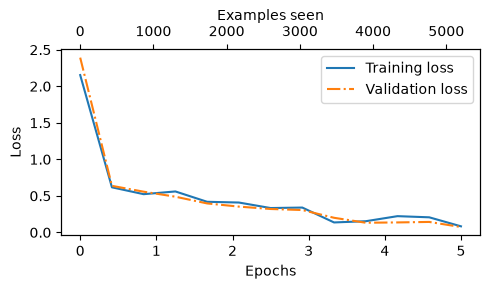

In [107]:
import matplotlib.pyplot as plt
def plot_values(
    epochs_seen, examples_seen, train_values, val_values,
    label="loss"):
    fig, ax1 = plt.subplots(figsize=(5, 3))

    ax1.plot(epochs_seen, train_values, label=f"Training {label}")
    ax1.plot(
        epochs_seen, val_values, linestyle="-.",
        label=f"Validation {label}"
        )
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel(label.capitalize())
    ax1.legend()

    ax2 = ax1.twiny()
    ax2.plot(examples_seen, train_values, alpha=0)
    ax2.set_xlabel("Examples seen")
    fig.tight_layout()
    plt.savefig(f"{label}-plot.pdf")
    plt.show()
epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
examples_seen_tensor = torch.linspace(0, examples_seen, len(train_losses))
plot_values(epochs_tensor, examples_seen_tensor, train_losses, val_losses)

# Section 6.5: Choosing the Number of Epochs

Choosing the optimal number of training epochs requires analyzing the trendlines of your loss and accuracy plots to balance model convergence against generalization error.

---

## 1. The Epoch Selection Framework

There is no universal recommendation for the perfect number of epochs, as it depends entirely on your dataset and task difficulty. However, **5 epochs** serves as an excellent empirical starting point.

* **Early Overfitting (Decrease Epochs):** If your training loss continues to fall but the validation loss curves upward (as seen in loss plots like **Figure 6.16**), the model is memorizing noise in the training split. You should halt training early or reduce the total epochs.
* **Underfitting (Increase Epochs):** If the trendlines suggest that validation loss is still steadily declining and has room to improve with further training, you should extend the number of epochs.
* **Optimal Balance:** In this concrete setup, **5 epochs** proves reasonable. The validation loss is near zero, there are no signs of early overfitting, and the training and test metrics remain tightly aligned.

---

## 2. The Generalization Gap: Train vs. Validation vs. Test

It is perfectly standard for evaluation metrics to present a subtle hierarchy in performance:

$$\text{Training Accuracy} \ge \text{Validation Accuracy} > \text{Test Accuracy}$$

The slight discrepancy between training and test performance indicates minimal overfitting. Typically, validation set accuracy lands slightly higher than test set accuracy because model development inherently involves tuning hyperparameters to perform well on the validation set. Consequently, these settings might not generalize quite as effectively to the completely unseen test set.

---

## 3. Regularization Strategies to Minimize the Gap

If the variance between your training/validation metrics and your test metrics begins to widen significantly, you can combat this overfitting by introducing regularization techniques directly into your configuration:

* **Increase the Dropout Rate (`drop_rate`):** Randomly zeroing out a higher percentage of hidden unit activations during training passes forces the network to learn robust, redundant features rather than relying on brittle, highly specific token pathways.
* **Apply Weight Decay (`weight_decay`):** Configure the optimizer to penalize large weight magnitudes (L2 regularization). This restricts the internal weight matrices to smaller, smoother values, preventing the model from fitting high-frequency noise in the training data.

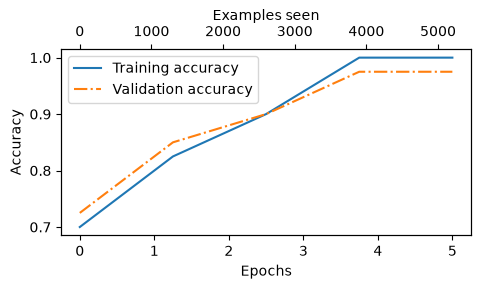

In [108]:
epochs_tensor = torch.linspace(0, num_epochs, len(train_accs))
examples_seen_tensor = torch.linspace(0, examples_seen, len(train_accs))

plot_values(
    epochs_tensor, examples_seen_tensor, train_accs, val_accs,
    label="accuracy"
)

In [109]:
train_accuracy = calc_accuracy_loader(train_loader, model, device)
val_accuracy = calc_accuracy_loader(val_loader, model, device)
test_accuracy = calc_accuracy_loader(test_loader, model, device)
print(f"Training accuracy: {train_accuracy*100:.2f}%")
print(f"Validation accuracy: {val_accuracy*100:.2f}%")
print(f"Test accuracy: {test_accuracy*100:.2f}%")

Training accuracy: 97.21%
Validation accuracy: 97.32%
Test accuracy: 95.67%


## 6.8 Using the LLM as a spam classifier

# Section 6.8: Model Inference

We are ready to use our fine-tuned GPT-2 model to classify raw, unseen messages as spam or ham (**Figure 6.18**). 

The `classify_review` function handles this by mirroring our training preprocessing steps:

1. **Preprocessing:** Tokenizes the raw text input identically to the `SpamDataset` pipeline to ensure consistency.
2. **Prediction:** Runs a forward pass with gradient tracking disabled (`torch.no_grad()`). Because of causal self-attention, it extracts the logits of the **very last token** to predict the integer class label.
3. **Mapping:** Translates the predicted integer back to a human-readable string (`"spam"` or `"ham"`).


## Listing 6.12 Using the model to classify new texts

In [110]:
import torch

def classify_review(
    text, model, tokenizer, device, max_length=None, pad_token_id=50256
):
    model.eval()
    
    # 1. Tokenize input text
    input_ids = tokenizer.encode(text)
    
    # 2. Determine max length using index 0 for supported context length
    supported_context_length = model.pos_emb.weight.shape[0]
    if max_length is None:
        max_length = supported_context_length
    else:
        max_length = min(max_length, supported_context_length)
        
    # 3. Truncate and pad sequence
    input_ids = input_ids[:max_length]
    input_ids += [pad_token_id] * (max_length - len(input_ids))

    # 4. Create tensor with batch dimension [1, max_length]
    input_tensor = torch.tensor(input_ids, device=device).unsqueeze(0)

    # 5. Extract logits for the last token position under no_grad
    with torch.no_grad():
        logits = model(input_tensor)[:, -1, :]
        
    # 6. Map predicted label index to class name
    predicted_label = torch.argmax(logits, dim=-1).item()
    return "spam" if predicted_label == 1 else "not spam"

In [111]:
text_1 = (
    "You are a winner you have been specially"
    " selected to receive $1000 cash or a $2000 award."
)
print(classify_review(
    text_1, model, tokenizer, device, max_length=train_dataset.max_length
))

spam


In [112]:
text_2 = (
    "Hey, just wanted to check if we're still on"
    " for dinner tonight? Let me know!"
)
print(classify_review(
 text_2, model, tokenizer, device, max_length=train_dataset.max_length
))

not spam


In [113]:
#SAVING THE FILE
torch.save(model.state_dict(), "review_classifier.pth")

In [115]:
#LOADING THE MODEL
model_state_dict = torch.load("review_classifier.pth", map_location=device)
model.load_state_dict(model_state_dict)

<All keys matched successfully>

## Chapter 6 Summary: Classification Fine-Tuning

*   **Fine-Tuning Paradigms:** LLMs can be adapted for specialized tasks using distinct optimization tracks, primarily **classification fine-tuning** (predicting discrete category labels) or **instruction fine-tuning** (following multi-turn prompt directives).
*   **Architectural Modification:** Transitioning an LLM from pretraining to classification requires replacing the broad vocabulary projection head with a compact classification layer. For binary classification (e.g., spam vs. ham), the output nodes drop from the vocabulary dimension of **50,256** down to just **2**.
*   **Objective Shift:** The training objective changes from self-supervised next-token prediction to supervised category assignment. Instead of generating the subsequent token in a sequence, the model updates its weights to output the target class token distribution.
*   **Data Pipeline Continuity:** The foundational data engineering pipeline remains identical to pretraining. Raw textual inputs are encoded into structured token ID arrays, mapped to positional embeddings, and passed to a pre-initialized base model weight matrix.
*   **Loss & Metrics:** Training still utilizes standard **Cross-Entropy Loss**, but the calculation shifts to target only the final sequence token logit. Performance evaluation transitions from token perplexity to standard **classification accuracy** (the percentage of correctly predicted inputs out of the total test set).